## Redes clasificación 1

In [125]:
#importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

In [127]:
seed=12345 #fijamos la semilla de aleatorización para que sea la misma en todo el proceso
#Reemplaza con la ruta correcta y nombre de tu archivo
file_path = '/Users/biblioadmin/Library/CloudStorage/OneDrive-UniversidadComplutensedeMadrid(UCM)/Documentos/Titulo Propio/Machine Learning/Redes Neuronales/Python/Datasets/SAheart.csv' 
#convertir a data frame el archivo
df = pd.read_csv(file_path)
print(df.head())
#La variable de interés es chd, binaria Si/No
#analizamos la frecuencia de cada clase
print(f'\n Instancias: {df.shape[0]}; Variables: {df.shape[1]}')
print(f'\nLa frecuencia de cada clase es: \n{df.chd.value_counts()}')

   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age chd
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52  Si
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63  Si
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46  No
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58  Si
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49  Si

 Instancias: 462; Variables: 10

La frecuencia de cada clase es: 
chd
No    302
Si    160
Name: count, dtype: int64


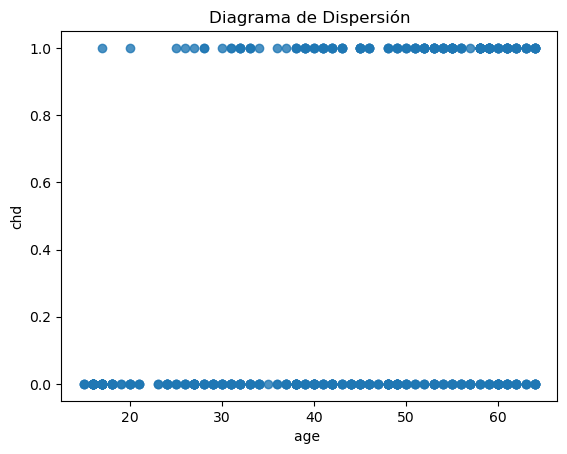

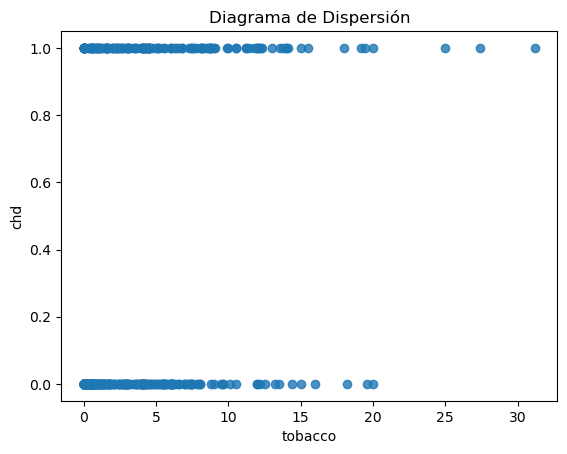

In [131]:
#representamos la relación enre la variable de interés y las variables input
df['chd_numeric'] = df['chd'].apply(lambda x: 1 if x == 'Si' else 0)
# Crear el diagrama de dispersión con regresión
sns.regplot(x=df['age'], y=df['chd_numeric'], ci=None,fit_reg=False)
plt.xlabel('age ')
plt.ylabel('chd')
plt.title('Diagrama de Dispersión')
plt.show()
# Crear el diagrama de dispersión con regresión
sns.regplot(x=df['tobacco'], y=df['chd_numeric'], ci=None,fit_reg=False)
plt.xlabel('tobacco')
plt.ylabel('chd')
plt.title('Diagrama de Dispersión')
plt.show()

In [133]:
import pandas as pd

y_series = pd.Series(df['chd_numeric'])
print(y_series.value_counts(normalize=True))


chd_numeric
0    0.65368
1    0.34632
Name: proportion, dtype: float64


In [135]:
# Si se quiere categorizar la variable de respuesta (útil cuando tiene 1/0)
#df['chd'] = df['chd'].apply(lambda x: 'Yes' if x == 1 else 'No')
#en nuestro caso, cambiamos Si por Yes
df['chd'] = df['chd'].apply(lambda x: 'Yes' if x == 'Si' else 'No')
print(df.head())

   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd  \
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52  Yes   
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63  Yes   
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46   No   
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58  Yes   
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49  Yes   

   chd_numeric  
0            1  
1            1  
2            0  
3            1  
4            1  


In [137]:
# hay valores perdidos?
df.isna().sum()

sbp            0
tobacco        0
ldl            0
adiposity      0
famhist        0
typea          0
obesity        0
alcohol        0
age            0
chd            0
chd_numeric    0
dtype: int64

Preparamos la base de datos para la aplicación de redes neuronales:

    - Estandarizar/normalizar variables continuas
    - Convertir a dummies las variables categóricas
    - Evitar missing

In [140]:
# organiza las variables según su rol y naturaleza
# determina variable objetivo
target = "chd"
#hacer una lista con las variables input numericas
num_cols = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
#hacer una lista con las variables input categóricas
cat_cols = ['famhist']

In [142]:
#Convertir a dummies las categóricas
#solo hay una variable categórica, transformación fácil
df[['famhist']] = pd.get_dummies(df[['famhist']],drop_first=True)
# drop_first en la función get_dummies de pandas se utiliza para controlar si se debe eliminar 
#la primera columna de las variables dummy que se generan. 
#Cuando drop_first se establece en True, se elimina la primera columna de cada conjunto de variables dummy, lo que ayuda a evitar la multicolinealidad en modelos lineales
#otra opción
cat_cols = ColumnTransformer(transformers=[ ('ohe', OneHotEncoder(drop='first'), cat_cols)], 
                                                  remainder='passthrough')


In [144]:
#Normalizar variables numericas
#Si se quisieran estandarizar, scaler=StandardScaler()
scaler = MinMaxScaler() #selecciona el transformador
X = df[num_cols] #selecciona las variables numéricas que se quieren transformar y las guarda en un nuevo dataframe
X_scale = pd.DataFrame(scaler.fit_transform(X)) #guarda el resultado de la transformación de las variables de X en X_scale
X_scale.columns = X.columns #para simplificar los nombres, asigna a las columnas de X_scale los nombres de las variables de X_num
df[num_cols] = X_scale
print(df.head())

        sbp   tobacco       ldl  adiposity  famhist     typea   obesity  \
0  0.504274  0.384615  0.331010   0.457902     True  0.553846  0.332497   
1  0.367521  0.000321  0.239024   0.611748    False  0.646154  0.444479   
2  0.145299  0.002564  0.174216   0.714406     True  0.600000  0.452949   
3  0.589744  0.240385  0.378397   0.875245     True  0.584615  0.542346   
4  0.282051  0.435897  0.175610   0.588531     True  0.723077  0.354141   

    alcohol       age  chd  chd_numeric  
0  0.660371  0.755102  Yes            1  
1  0.013996  0.979592  Yes            1  
2  0.025885  0.632653   No            0  
3  0.164821  0.877551  Yes            1  
4  0.389565  0.693878  Yes            1  


### Otra forma de normalizar los datos para mejorar el rendimiento de la red neuronal
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [146]:
# Separar las variables predictoras y la variable de respuesta.
# El grupo de variables predictoras se define y se fija
X = df[['tobacco','ldl','famhist']] #en X las variables ya están normalizadas y con dummies
y = df['chd']
#primer approach a red neuronal: definimos la estructura
red1 = MLPClassifier(random_state=seed, hidden_layer_sizes=(5),activation='tanh',
                     alpha=0.001,solver='adam',max_iter=1000)
# Dividir los datos en entrenamiento y test (20% de los datos para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=seed)
# Construir el modelo de red ajustando los pesos a datos de train
red1.fit(X_train, y_train)


MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=5,
              max_iter=1000, random_state=12345)

# OJO
Al hacer clasificación binaria utilizando un clasificador MLP (perceptrón multicapa), **generalmente solo se necesita un nodo en la capa de salida** para predecir la clase. Sin embargo, es común que los modelos de clasificación binaria tengan dos nodos en la capa de salida: uno para cada clase. En este caso, el **modelo devuelve las probabilidades de ambas clases** 

In [148]:
# Niveles de la variable a predecir
print(red1.classes_)
# Nombre de las variables predictoras
print(red1.feature_names_in_)
# Cantidad de iteraciones necesarias para la convergencia, 
#así se puede volver a entrenar el modelo ajustando este parámetro para tener menos coste computacional
print(red1.n_iter_) #no ha hecho falta iterar tanto
#ver los coeficientes de cada enlace
# Acceder a los coeficientes (pesos) de cada capa
print(red1.coefs_)
#si se quiere ver qué atributos podemos analizar en el modelo
#dir(red1)

['No' 'Yes']
['tobacco' 'ldl' 'famhist']
632
[array([[ 1.55167728,  0.36617059, -1.70048717, -1.58244206, -1.01173305],
       [ 0.46190905,  0.74298334, -0.7184239 , -0.40557776, -0.43296657],
       [ 0.0868709 ,  0.31289518, -0.66901706, -0.58714767, -0.2255567 ]]), array([[ 0.44308391],
       [ 0.24281668],
       [-0.74956687],
       [-0.8829639 ],
       [-0.66749368]])]


In [150]:
# ES IMPORTANTE QUE LA DISTRIBUCIÓN DE LAS CLASES SEA 'SIMILAR' EN TRAIN Y TEST.
print(f'La frecuencia de cada clase en train es: \n{y_train.value_counts(normalize=True)}')
print(f'\nLa frecuencia de cada clase en test es: \n{y_test.value_counts(normalize=True)}')

La frecuencia de cada clase en train es: 
chd
No     0.653117
Yes    0.346883
Name: proportion, dtype: float64

La frecuencia de cada clase en test es: 
chd
No     0.655914
Yes    0.344086
Name: proportion, dtype: float64


- Probar con 200 iteraciones, qué pasa?

- Modificar la estructura de red: ¿qué cantidad de nodos ocultos es apropiada?
En este ejemplo, k=3. Como hay 469 observaciones y hemos usado tres variables input, si se reservan aproximandamente 20 observaciones para cada parámetro,la fórmula nos dice que una cantidad razonable de nodos ocultos es 5-6

In [152]:
#una vez ajustado el modelo en datos de train, lo evaluamos en datos de test
# Realizar predicciones en el conjunto de prueba
y_pred = red1.predict(X_test)

# Calcular la precisión del modelo
precision = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo en test: {precision:.4f}")

# Mostrar la matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(matriz_confusion)

# Mostrar el informe de clasificación
informe_clasificacion = classification_report(y_test, y_pred)
print("Informe de clasificación:")
print(informe_clasificacion)

Precisión del modelo en test: 0.6882
Matriz de confusión:
[[55  6]
 [23  9]]
Informe de clasificación:
              precision    recall  f1-score   support

          No       0.71      0.90      0.79        61
         Yes       0.60      0.28      0.38        32

    accuracy                           0.69        93
   macro avg       0.65      0.59      0.59        93
weighted avg       0.67      0.69      0.65        93



In [156]:
import pandas as pd

y_series = pd.Series(y)
print(y_series.value_counts(normalize=True))


chd
No     0.65368
Yes    0.34632
Name: proportion, dtype: float64


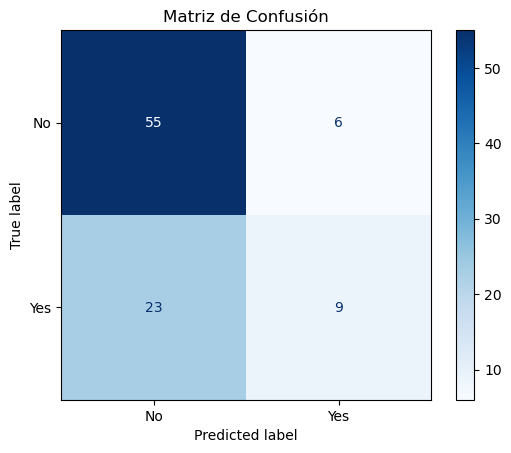

In [164]:
#otra forma de mostrar la matriz de confusión
#ConfusionMatrixDisplay, que espera etiquetas binarias

## OJO: ajustamos el label encoder con test y se lo aplicamos a pred. En este caso da un poco igual pero para mantener la forma de aplicación
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test) 
y_pred_encoded = label_encoder.fit_transform(y_pred)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder1.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

In [166]:
#una forma de analizar el overfitting es comparando la medida de bondad en train/test
#si hay mucha diferencia, es porque el modelo está sobreajustado
#si ambas son muy malas, es porque el modelo está poco ajustado
# Realizar predicciones en el conjunto de prueba
y_pred_tr = red1.predict(X_train)

# Calcular la precisión del modelo
precision_tr = accuracy_score(y_train, y_pred_tr)
print(f"Precisión del modelo en train: {precision_tr:.4f}")
print(f"Precisión del modelo en test: {precision:.4f}")
#este es un ejemplo de modelo sobreajustado

Precisión del modelo en train: 0.7209
Precisión del modelo en test: 0.6882


In [168]:
#validación cruzada para una evaluación más robusta del modelo
#importante cambiar el tipo ed scoring atendiendo al tipo de problema
cv_scores = cross_val_score(red1, X, y, cv=5, scoring='accuracy')
cv_precision_mean = np.mean(cv_scores)

print(f'Precisión promedio mediante validación cruzada: {cv_precision_mean:.4f}')

Precisión promedio mediante validación cruzada: 0.7099


### OJO
No es necesario convertir explícitamente la variable **respuesta** en una variable dummy (0 y 1) cuando se utiliza **MLPClassifier** de sklearn para problemas de clasificación binaria. 

MLPClassifier acepta tanto **etiquetas numéricas** como etiquetas de **texto** para la variable **dependiente**. El algoritmo manejará internamente la conversión adecuada de las etiquetas.

Sin embaro, las variables **independientes** **sí** deben convertirse a numéricas explícitamente:
- Generalmente, y lo que aquí se propone, es convertirlas a dummies
- En algunas propuestas, se convierten a variables ordinales

## Si se quiere dividir en tr/v/ts
### Paso 1: División en entrenamiento y test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

### Paso 2: División del conjunto temporal en validación y test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Ejemplo con etiquetas numéricas (0 y 1)

In [170]:
from sklearn.datasets import make_classification

# Crear un conjunto de datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo MLPClassifier
mlp = MLPClassifier(random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Evaluar el modelo
print(mlp.score(X_test, y_test))


0.84


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Ejemplo con etiquetas de clase (clase 0 y clase 1)

In [172]:
# Crear un conjunto de datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Convertir las etiquetas numéricas a etiquetas de texto
y = ['class0' if label == 0 else 'class1' for label in y]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo MLPClassifier
mlp = MLPClassifier(random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Evaluar el modelo
print(mlp.score(X_test, y_test))

0.84


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
